In [1]:
import sys, os
os.chdir(os.path.abspath('..'))
sys.path.insert(0, os.getcwd())

# Gravity harmonics: ToF7, CMS, and a Militzer & Hubbard (2024) validation

A rotating planet is not a sphere, and its external gravity field carries the fingerprint of its interior density distribution through the zonal harmonics $J_2, J_4, J_6, \ldots$. These are the quantities *Juno* has measured for Jupiter to extraordinary precision ($J_2 = 14696.5735 \pm 0.0017$, $J_4 = -586.6085 \pm 0.0024$, $J_6 = 34.2007 \pm 0.0067$, all $\times 10^6$; Durante et al. 2020). If you model giant planets, sooner or later you will need to compute these numbers. `ORCHARD` gives you two ways to do it.

The first is the Theory of Figures at 7th order (`utils/TOF7.py`, `tof_order = 7`, with 4th order also available). This is a perturbative expansion in the rotational parameter, and it is fast enough to run inside the Henyey solve at every timestep of a Gyr evolution.

The second is the Concentric Maclaurin Spheroid method (`utils/cms_hubbard.py`, `gravity_method = cms`) of Hubbard (2013), in which the planet is a stack of constant-density spheroids whose shapes are iterated to equipotentials. This is the method Militzer & Hubbard (2024, hereafter MH24) used for their *Juno*-constrained Jupiter models. It is nonperturbative but slower, so treat it as a validation and post-processing backend rather than something to put in the evolution inner loop.

In this tutorial we will build a rotating static Jupiter (see `tutorial_static_structures.ipynb` for the static-model machinery), compute its harmonics, and then validate both backends against MH24's published models. Their paper (*Study of Jupiter's interior: Comparison of 2, 3, 4, 5, and 6 layer models*, Icarus 411, 115955) ships nine machine-readable interior models (Militzer 2024, Zenodo, doi:10.5281/zenodo.10471389), which we redistribute in [`validation/mh24/data/`](../validation/mh24/). Please cite both the paper and the dataset if you use them.

## A rotating static Jupiter with ToF7

Rotation enters through four config keys. `rotation = True` adds the centrifugal term to hydrostatic balance, `tof_calc = True` and `tof_order = 7` compute the figure and harmonics, and `period` sets the rotation period in seconds (35730 s is Jupiter's System III, and also what MH24 use).

**NOTE**: One thing must be understood before trusting any static $J_n$. The rotation rate and the structure are coupled, because `ORCHARD` sets $\omega$ from angular momentum bookkeeping using the structure's moment of inertia, while the structure itself depends on $\omega$ through the centrifugal term. In an evolution run this self-consistency builds up naturally across timesteps. In a one-shot static build it does not, and a single `init=True` call seeds $\omega$ off the initial guess, which can over-inflate $J_2$ by several percent. The fix is to iterate the structure, figure, and $\omega$ until the equatorial radius stops moving, usually about six passes. That is what the cell below does, and it is the single most important pattern in this notebook.

In [2]:
import numpy as np

from utils import common, const
c = common.config
c["initial"]["M_factor"]  = "317.907"
c["initial"]["S_ini"]     = "6.5"
c["initial"]["Y_ini"]     = "0.277"
c["initial"]["Z_ini"]     = "0.02"
c["core"]["mass_core"]    = "10.0"
c["core"]["mass_core_fe"] = "0.0"
c["hydrostatic_equilibrium"]["rotation"] = "True"
c["hydrostatic_equilibrium"]["tof_calc"] = "True"
c["hydrostatic_equilibrium"]["tof_order"] = "7"
c["hydrostatic_equilibrium"]["period"] = "35730"          # Jupiter System III [s]
c["hydrostatic_equilibrium"]["hse_adaptive_alpha"] = "False"

from initial import initialize_grid
from hydrostatic import hydrostatic_equilibrium

N = int(c["general"]["N"])
M_planet = float(c["initial"]["M_factor"]) * const.mearth
r_b0, p0, m_b, dm, S, Y, Z, f_rock, kcore, kcore_fe = initialize_grid(
    N, M_planet, 6.5, 0.277, 0.02, float(c["initial"]["f_rock_ini"]))
kcore = N if kcore == -1 else kcore
kcore_fe = N if kcore_fe == -1 else kcore_fe

# Iterate structure <-> figure <-> omega to self-consistency
log_r, log_p, logt = np.log(r_b0), np.log(p0), np.zeros_like(S)
omega_prev, init, R_eq_prev = 0.0, True, np.inf
for it in range(12):
    out = hydrostatic_equilibrium(S, log_r, log_p, m_b, Y, Z, f_rock,
                                  kcore, kcore_fe, omega_prev, 0.0,
                                  logt_old=logt, init=init)
    r_b, p, rho, temp, S, g, omega, j2n, shapes, niter = out
    R_eq = j2n[5]
    print(f"pass {it}: omega = {omega:.4e} rad/s, "
          f"R_eq = {R_eq/1e5:9.1f} km, J2 = {j2n[0]:10.2f} x 1e6")
    if abs(R_eq - R_eq_prev) / R_eq < 1e-6 and it >= 2:
        break
    R_eq_prev = R_eq
    log_r, log_p, logt = np.log(r_b), np.log(p), np.log10(temp)
    omega_prev, init = omega, False

J2, J4, J6, J8, oblat, R_eq, R_pol, MoI = j2n
print(f"\nConverged static Jupiter:")
print(f"  J2 = {J2:10.3f}   J4 = {J4:9.3f}   J6 = {J6:7.3f}   J8 = {J8:7.3f}  (x 1e6)")
print(f"  R_eq = {R_eq/1e5:8.1f} km   R_pol = {R_pol/1e5:8.1f} km   "
      f"oblateness = {oblat:.5f}   MoI/(M R_eq^2) = {MoI/(m_b[0]*R_eq**2):.4f}")

Loading EOS ...


Ready!


pass 0: omega = 1.6821e-04 rad/s, R_eq =   74916.9 km, J2 =   15075.37 x 1e6


pass 1: omega = 1.6182e-04 rad/s, R_eq =   74678.2 km, J2 =   13941.43 x 1e6


pass 2: omega = 1.6231e-04 rad/s, R_eq =   74695.9 km, J2 =   14026.26 x 1e6


pass 3: omega = 1.6227e-04 rad/s, R_eq =   74694.6 km, J2 =   14019.91 x 1e6


pass 4: omega = 1.6227e-04 rad/s, R_eq =   74694.7 km, J2 =   14020.39 x 1e6


pass 5: omega = 1.6227e-04 rad/s, R_eq =   74694.7 km, J2 =   14020.35 x 1e6

Converged static Jupiter:
  J2 =  14020.354   J4 =  -535.330   J6 =  29.690   J8 =  -2.022  (x 1e6)
  R_eq =  74694.7 km   R_pol =  70014.2 km   oblateness = 0.06266   MoI/(M R_eq^2) = 0.2620


Watch how the loop behaves. Pass 0 (the naive single call) starts with an inflated $J_2$, and the iterations walk it down as $\omega$ and the structure come into agreement. By the last pass the equatorial radius has stopped moving at the $10^{-6}$ level. The `j2n` return unpacks as `[J2, J4, J6, J8, oblateness, R_eq, R_pol, MoI]`, with the harmonics scaled by $10^6$ and the moment of inertia in g cm$^2$, which is why we normalize by $MR_{\rm eq}^2$ when printing.

Don't expect *Juno*'s numbers from this model. A uniform-composition, $S = 6.5$ planet with a 10 M$_\oplus$ compact core is not Jupiter's actual interior, and matching the real $J_4$ and $J_6$ requires a dilute core and a tuned $Z$ profile, which is the whole subject of MH24. What we should demand is that the machinery is exact, and that is what the rest of this notebook establishes.

## The CMS backend

`ORCHARD` also ships the method MH24 themselves used, Concentric Maclaurin Spheroids, in `utils/cms_hubbard.py`. You can run it two ways. Setting `gravity_method = cms` in a config makes the Henyey solver use it in place of ToF at every iteration, which is correct but slow, so reserve it for short runs or final snapshots. Alternatively, call `get_moments_cms_from_mean()` directly on a converged structure as a post-processing step. It accepts the same inputs ToF consumes (volumetric radii, density, total mass, and $\omega$) and returns the same 8-element `j2n` layout.

Before trusting either backend on our own models, though, we should validate both against published ground truth. That is what the MH24 dataset is for.

## Reproducing MH24, part 1: the gravity solvers on their own density

Take MH24's published density profiles and check that our solvers reproduce their published harmonics. Their `layers` tables give, per spheroid, the equatorial and volumetric radii, cumulative mass `CMass`, $P$, $T$, $\rho$, and composition. Their `harmonics` tables split each $J_n$ into a static interior part `J_Int` and a wind correction. ToF and CMS compute the static field, so `J_Int` is the comparison target.

**WARNING**: There is a data-consistency gotcha here that cost us a debugging session. ToF requires the density and enclosed-mass arrays to be mutually consistent, $m(l) = \int 4\pi l'^2 \rho\, dl'$. MH24's `rho` column carries their CMS discretization (spherically integrating it gives 1.0021 M$_J$, not the exact `CMass` of 1.0), and feeding that raw pairing to ToF produces a spurious $+0.5\%$ $J_2$ offset. It shows up in ToF4 and ToF7 alike, which is how you know it is an input inconsistency and not a solver bug. The fix is to treat `CMass` as authoritative and derive $\rho = dM/dV$ from it. The cell below shows both, so you can see the pitfall with your own eyes:

In [3]:
sys.path.insert(0, os.path.join(os.getcwd(), 'validation', 'mh24'))
import mh24_io
from utils.TOF7 import get_moments7

OMEGA = 2 * np.pi / 35730.0
ref = "10969"                                  # MH24's five-layer reference model
L_ = mh24_io.load_layers(ref)
H = mh24_io.load_harmonics(ref)

l = L_["rS"][::-1] * const.rj_eq               # volumetric radii, center -> surface [cm]
m = L_["CMass"][::-1] * const.M_jup            # authoritative cumulative mass [g]

# Consistent density: rho = dM/dV from CMass
V = 4.0 / 3.0 * np.pi * l**3
rho_ok = np.gradient(m, V)
j_ok, _ = get_moments7(l, rho_ok, m, OMEGA)

# The pitfall: raw rho column paired with CMass
rho_naive = L_["rho"][::-1]
j_bad, _ = get_moments7(l, rho_naive, m, OMEGA)

print(f"{'':>6}{'MH24 J_Int':>14}{'ToF7 (dM/dV)':>15}{'rel':>11}{'ToF7 (raw rho)':>17}{'rel':>11}")
for k, n in enumerate((2, 4, 6, 8)):
    cms_val = H[n]["int"] * 1e6
    print(f"J{n:<5}{cms_val:14.4f}{j_ok[k]:15.4f}{(j_ok[k]-cms_val)/cms_val:11.1e}"
          f"{j_bad[k]:17.4f}{(j_bad[k]-cms_val)/cms_val:11.1e}")
print(f"\nR_eq check: {j_ok[5]/1e5:.1f} km (MH24 fix 71492); "
      f"oblateness {j_ok[4]:.5f} (observed 0.06487)")

          MH24 J_Int   ToF7 (dM/dV)        rel   ToF7 (raw rho)        rel
J2        14696.4484     14696.3910   -3.9e-06       14765.5848    4.7e-03
J4         -586.8462      -586.8348   -2.0e-05        -590.2300    5.8e-03
J6           34.4692        34.4680   -3.5e-05          34.6972    6.6e-03
J8           -2.4983        -2.4981   -5.5e-05          -2.5167    7.4e-03

R_eq check: 71492.0 km (MH24 fix 71492); oblateness 0.06488 (observed 0.06487)


With the consistent density, ToF7 lands on MH24's CMS values to a few parts in $10^{5}$ on $J_2$, recovers their fixed equatorial radius to sub-km, and matches Jupiter's observed oblateness. The naive density pairing sits a full $0.5\%$ off everything. Input hygiene matters just as much as the solver.

Now the same test for our CMS implementation. Since this is MH24's own method, the residual here measures only the spheroid-count discretization (we downsample their 2049 layers for speed; push `nlayers` up and watch it converge):

In [4]:
from utils import cms_hubbard as C
import json, time

idx = np.unique(np.linspace(0, len(L_["rE"]) - 1, 512).astype(int))
lam_eq = L_["rE"][idx] * const.rj_eq          # CMS is parameterized by EQUATORIAL radii
rho_sph = L_["rho"][idx]                       # here the raw rho column IS correct: it
                                               # is what MH24's own CMS mass sum used
t0 = time.time()
j_cms, zeta, info = C.get_moments_cms(lam_eq, rho_sph, const.M_jup, OMEGA,
                                      G=const.G, kmax=10, L=48)
print(f"CMS, 512 spheroids: {time.time()-t0:.1f} s, {info['iters']} shape iterations")
print(f"{'':>6}{'MH24 J_Int':>14}{'our CMS':>14}{'rel':>11}")
for k, n in enumerate((2, 4, 6, 8)):
    cms_val = H[n]["int"] * 1e6
    print(f"J{n:<5}{cms_val:14.4f}{j_cms[k]:14.4f}{(j_cms[k]-cms_val)/cms_val:11.1e}")

# Stored convergence study (validation/mh24/results/cms_validation.json):
conv = json.load(open('validation/mh24/results/cms_validation.json'))['convergence']
print(f"\nSpheroid-count convergence toward MH24 (J2 rel):")
for row in conv:
    print(f"  n = {row['n']:>5}: {row['rel'][0]:+.2e}")

CMS, 512 spheroids: 0.1 s, 28 shape iterations
          MH24 J_Int       our CMS        rel
J2        14696.4484    14692.7041   -2.5e-04
J4         -586.8462     -586.6484   -3.4e-04
J6           34.4692       34.4553   -4.0e-04
J8           -2.4983       -2.4971   -4.6e-04

Spheroid-count convergence toward MH24 (J2 rel):
  n =   128: -9.63e-04
  n =   256: -6.04e-04
  n =   512: -2.55e-04
  n =  1024: -9.70e-05
  n =  2049: -1.50e-05


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


The $J_2$ residual shrinks monotonically as the spheroid count approaches MH24's native 2049, so the remaining difference is discretization, not algorithm. Note the run time, too. Seconds per call is fine for post-processing, and it is also exactly why `ToF7` holds the evolution inner loop.

## Mesh resolution: where CMS pays and ToF7 doesn't

There is a practical subtlety worth demonstrating rather than asserting. An evolution code's mass mesh is built for evolution, with zones concentrated where the physics needs them (the surface, composition boundaries) and not where a gravity integrator would like them. CMS represents the planet as constant-density spheroids, so its accuracy degrades on coarse, unevenly spaced profiles. ToF7 consumes the enclosed-mass array directly and is far more forgiving. We can isolate this cleanly by putting MH24's reference planet, where we know the right answer, onto this notebook's 600-zone evolution mesh and asking both solvers for $J_2$:

In [5]:
from utils.cms_hubbard import get_moments_cms_from_mean

# MH24's reference planet, interpolated onto OUR evolution-mesh zone distribution
r_mesh = (r_b[:-1] / r_b[0]) * l[-1]           # our normalized mesh x their radius
rho_mesh = np.interp(r_mesh[::-1], l, rho_ok)[::-1]
m_mesh = np.interp(r_mesh[::-1], l, m)[::-1]

j_t_mesh, _ = get_moments7(r_mesh[::-1], rho_mesh[::-1], m_mesh[::-1], OMEGA)
j_c_mesh, _, _ = get_moments_cms_from_mean(r_mesh, rho_mesh, const.M_jup, OMEGA,
                                           G=const.G, kmax=10, L=48)
J2t = H[2]["int"] * 1e6
print(f"MH24 reference planet on a {len(r_mesh)}-zone evolution mesh:")
print(f"  ToF7: J2 = {j_t_mesh[0]:12.3f}   rel. error = {(j_t_mesh[0]-J2t)/J2t:+.1e}")
print(f"  CMS : J2 = {j_c_mesh[0]:12.3f}   rel. error = {(j_c_mesh[0]-J2t)/J2t:+.1e}")

MH24 reference planet on a 500-zone evolution mesh:
  ToF7: J2 =    14696.609   rel. error = +1.1e-05
  CMS : J2 =    14621.539   rel. error = -5.1e-03


Same planet, same mesh, and ToF7 is still exact at the $10^{-5}$ level while CMS drops half a percent. That is pure discretization from the piecewise-constant spheroids on evolution-mesh spacing. The practical guidance follows.

Inside the evolution loop, use ToF7 (`tof_order = 7`, the default with `tof_calc = True`). It is fast and mesh-tolerant. For publication-grade CMS numbers, work from finely sampled profiles, as the validation suite does with MH24's native 2049-layer tables. Treat `gravity_method = cms` on a standard evolution mesh as a cross-check rather than a precision instrument, and check convergence with resolution before quoting digits. And when comparing to any published $J_n$, mind the data-consistency gotcha above, which is bigger than either solver's error.

Here is the full nine-model scorecard, built from the shipped validation results (every MH24 model, both solvers, on their density):

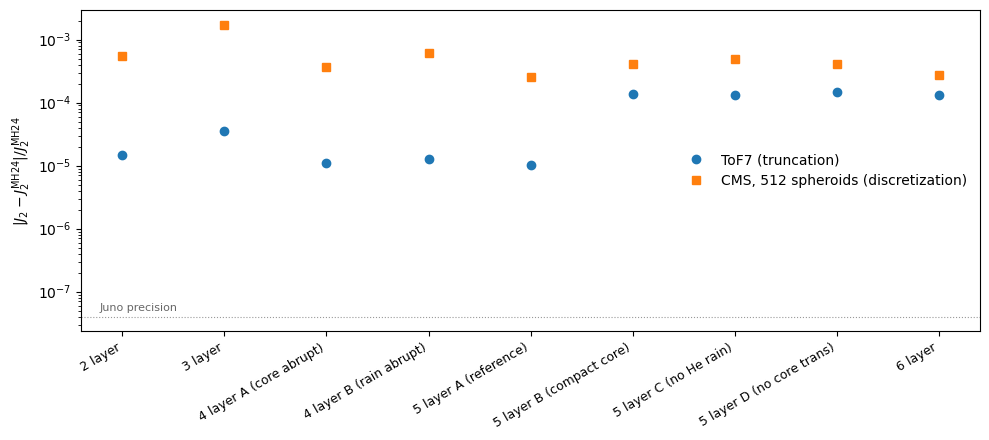

In [6]:
import matplotlib.pyplot as plt

allm = json.load(open('validation/mh24/results/cms_validation.json'))['all_models']
labels = [mh24_io.MODELS[d['mid']]['label'] for d in allm]
tof_rel = [abs(d['tof_rel']) for d in allm]
cms_rel = [abs(d['cms_rel']) for d in allm]

x = np.arange(len(allm))
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.semilogy(x, tof_rel, 'o', label='ToF7 (truncation)')
ax.semilogy(x, cms_rel, 's', label='CMS, 512 spheroids (discretization)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel(r'$|J_2 - J_2^{\rm MH24}| / J_2^{\rm MH24}$')
ax.axhline(4e-8, color='0.6', lw=0.8, ls=':')
ax.text(0.02, 5e-8, 'Juno precision', color='0.4', fontsize=8, transform=ax.get_yaxis_transform())
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Both solvers reproduce MH24 across all nine models. The coreless models sit at about $10^{-5}$ for ToF7, and the compact-core models slightly worse (about $10^{-4}$), since a sharp core-boundary density jump is where a perturbative expansion works hardest. The dotted line is a humbling reminder of what *Juno* delivers.

## Part 2: end-to-end, ORCHARD's EOS and solver against MH24

The sections above validated the gravity solvers given MH24's density. The stronger test rebuilds each model through `ORCHARD`'s own machinery. We take only MH24's composition profiles $Y(m)$ and $Z(m)$, derive the entropy from our `cd + aqua` EOS at their $(P, T)$, relax with our Henyey solver (iterated as above), and compare the resulting harmonics. That is `validation/mh24/run_one_model.py`, and one command reproduces everything:

```bash
python validation/mh24/run_all.py
```

The result, from `validation/mh24/results/`, relative to MH24's published values:

| model | $J_2$ | $J_4$ | $J_6$ |
|---|---|---|---|
| 2 layer | $-0.76\%$ | $-1.42\%$ | $-1.68\%$ |
| 3 layer | $-0.85\%$ | $-1.51\%$ | $-1.74\%$ |
| 4 layer A / B | $-0.83$ / $-0.85\%$ | $-1.47$ / $-1.51\%$ | $-1.70$ / $-1.77\%$ |
| **5 layer (reference)** | $-0.84\%$ | $-1.49\%$ | $-1.71\%$ |
| 5 layer B / C / D | $-0.83\%$ | $-1.7\%$ | $-2.1\%$ |
| 6 layer | $-0.83\%$ | $-1.64\%$ | $-2.05\%$ |

The decomposition is what makes this table meaningful. The gravity solver contributes about $10^{-5}$ (part 1), and the remaining $0.8\%$ on $J_2$ tracks the $0.5\%$ median density difference between our `cd + aqua` EOS and MH24's Militzer & Hubbard (2013) EOS, propagated through the structure ($R_{\rm eq}$ comes out $+0.35\%$). In other words, the harmonics machinery is exact and the physical difference between the codes is the equation of state. That is as it should be, and it is precisely the kind of statement a validation exercise exists to make. The EOS-difference theme continues in `tutorial_eos.ipynb`.

## Exercises

1. **ToF4 vs ToF7.** Restart the kernel, set `tof_order = 4`, and rebuild the static Jupiter. How much do $J_2$ and $J_4$ move? Compare that shift to the ToF7-vs-CMS gap and you will see why 7th order is the default.
2. **Saturn.** Rebuild at Saturn's mass (`M_factor = 95.16`), $S = 5.5$, `period = 38018`, and compare your $J_2$ and oblateness to Cassini's values. Saturn rotates faster relative to its density, so expect a much larger figure distortion.
3. **CMS resolution study.** Rerun the MH24 CMS cell at `nlayers` = 128, 256, 1024, and 2049, and plot the $J_2$ residual against the stored convergence table. At what resolution does discretization drop below the ToF7 truncation?
4. **The other seven models.** Loop the part-1 ToF7 test over every entry in `mh24_io.MODELS` and reproduce the coreless-vs-compact-core residual pattern in the scorecard figure.
5. **End-to-end with the ice mixture.** `run_one_model.py` accepts `Z_EOS=ice_mixture` as an environment variable, which is closer to MH24's envelope composition than pure water. Does it close any of the $0.8\%$?